<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Caso-taller:  Analizando el Delito en Chicago

En este caso-taller vamos a utilizar datos geográficos y estimación de densidad de kernel para analizar delitos en Chicago. Esta ciudad es muy famosa no sólo por haber sido el hogar del mafioso Al Capone, sino también por sus altas tasas de delitos. 

Para este taller obtuve datos del portal de la [ciudad de Chicago](https://www.chicago.gov/city/en/dataset/crime.html). La base de datos fue traducida y modificada para nuestras necesidades. Esta contiene todos los homicidios y robos que sucedieron entre el 1 de junio y el 31 de agosto de 2019.


## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Integrantes

Grupo 29

|**Nombre**|**Email**|
|---|---|
|Jaramillo Gómez Simon|s.jaramillo3@uniandes.edu.co|
|Mendoza Canales Hubert Ronald|h.mendozac@uniandes.edu.co|
|Montero Ramirez Daniel Eduardo|de.montero@uniandes.edu.co|

## Desarrollo


#### Config

In [1]:
from __future__ import annotations

%load_ext autoreload
%autoreload 2

# python
import shutil
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import session_info

# tools
from pathlib import Path
from inspect import cleandoc
from dataclasses import dataclass

# stats
import statsmodels.api as sm
from scipy import stats

# Geo
import folium
import geojsoncontour
import geopandas as gpd
from pyrosm import OSM, get_data
from geopy.distance import geodesic
from shapely.ops import nearest_points


# sklearn
from sklearn import model_selection
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# view
from IPython.display import IFrame
from bokeh.models import ColumnDataSource
from bokeh.plotting import figure, output_notebook, show
from bokeh.tile_providers import CARTODBPOSITRON, get_provider


# typings
from typing import List, Tuple, Dict, Any, Union, Optional

# setup
plt.style.use('seaborn')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('max_colwidth', None)

# decimals
np.set_printoptions(precision=6)

/usr/local/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


##### Información de Sesión

In [2]:
session_info.show(html=False)

-----
bokeh               2.4.3
folium              0.14.0
geojsoncontour      NA
geopandas           0.10.2
geopy               2.4.0
matplotlib          3.3.1
numpy               1.19.1
pandas              1.1.1
pyrosm              NA
scipy               1.7.3
seaborn             0.12.2
session_info        1.0.0
shapely             1.8.5
sklearn             0.23.2
statsmodels         0.13.5
-----
IPython             7.34.0
jupyter_client      7.4.9
jupyter_core        4.12.0
jupyterlab          2.1.1
notebook            6.0.3
-----
Python 3.7.17 (default, Jun 13 2023, 16:36:15) [GCC 8.3.0]
Linux-5.15.49-linuxkit-x86_64-with-debian-10.13
-----
Session information updated at 2025-09-20 17:40


### utils

In [3]:
# utils
# rutas absolutas: agnostico al sistema operativo
here: Path = Path.cwd().absolute()
data: Path = here / 'data'

chicago_areas_zip: Path = data / 'Areas_comunitarias_Chicago.zip'
chicago_areas_data: Path = data / 'Areas_comunitarias_Chicago'
chicago_crime_data: Path = data / 'Chicago_delitos_verano_2019.csv'

### 1.Carga de datos 

#### 1.1. Delitos

En la carpeta `data` se encuentra el archivo `Chicago_delitos_verano_2019.csv` cargue estos datos en su *cuaderno*. Describa brevemente el contenido de la base.

In [4]:
# Utilice este espacio para escribir el código.
@dataclass(frozen=True)
class Constant:
    SEP:str = ','
    ENCODING:str = 'utf-8'
    EMPTY_STR:str = ''
    SPACE_STR:str = ' '
    DOTS:str = '...'
    ONE:int = 1
    ZERO:int = 0
    
if not chicago_crime_data.exists():
    raise FileNotFoundError(cleandoc(f'''
        El archivo {chicago_crime_data} no existe.
        y colóquelo en el directorio {data}
    '''))
    
setup:Dict = dict(sep=Constant.SEP, encoding=Constant.ENCODING)

chicago_crime_df = pd.read_csv(chicago_crime_data, **setup)
chicago_crime_df.columns = chicago_crime_df.columns.str.strip()

print(chicago_crime_df.info())
display(chicago_crime_df.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17747 entries, 0 to 17746
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha                 17747 non-null  object 
 1   tipo_crimen           17747 non-null  object 
 2   nro_area_comunitaria  17747 non-null  int64  
 3   lat                   17747 non-null  float64
 4   lon                   17747 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 693.4+ KB
None


,fecha,tipo_crimen,nro_area_comunitaria,lat,lon
0,2019-06-01T05:07:00Z,homicidio,23,41.897950,-87.728625
1,2019-06-01T10:09:00Z,homicidio,71,41.753272,-87.648963
2,2019-06-01T12:46:00Z,homicidio,25,41.877622,-87.750728
3,2019-06-01T11:35:00Z,homicidio,16,41.960145,-87.699654
4,2019-06-02T09:39:00Z,homicidio,37,41.804773,-87.633256


(Utilice este espacio para describir su procedimiento)

#### 1.2. Barrios de Chicago

También en la carpeta `data` se encuentran los archivos con los polígonos de las áreas comunitarias en un archivo comprimido llamado `Areas_comunitarias_Chicago.zip`. Genere un mapa interactivo con un popup con el nombre del area comunitaria.

In [5]:
# Utilice este espacio para escribir el código.
# helper function
def preview_geoms(
        df: gpd.GeoDataFrame, 
        n: int = 5, 
        width: int = 80,
        colname: str = "geometry"
    ) -> pd.DataFrame:
    """
    Muestra las primeras n filas de un GeoDataFrame truncando 
    la columna 'geometry' por defecto.
    
    Parameters
    ----------
    df : gpd.GeoDataFrame
        GeoDataFrame a visualizar.
    n : int, optional
        Número de filas a mostrar (default=5).
    width : int, optional
        Máxima longitud de la representación de geometría (default=80).
    
    Returns
    -------
    pd.DataFrame
        DataFrame con geometría truncada para previsualización.
    """
    df_copy: pd.DataFrame = df.copy()
    tmp_name: str = colname + "_preview"
    
    if colname in df_copy.columns:
        truncated = df_copy[colname].astype(str).str.slice(0, width)
        truncated = np.where(
            df_copy[colname].astype(str).str.len() > width,
            truncated + Constant.DOTS,
            truncated
        )
        df_copy[tmp_name] = truncated
        
    return (df_copy
            .drop(columns=colname)
            .rename(columns={tmp_name:colname})
            .head(n))

# validar si esta descomprimido y si existe el archivo zip
if not chicago_areas_data.exists() or not any(chicago_areas_data.iterdir()):
    with zipfile.ZipFile(chicago_areas_zip, "r") as zip_ref:
        zip_ref.extractall(chicago_areas_data)
        
chicago_area_df: pd.DataFrame = gpd.read_file(chicago_areas_data)

print(chicago_area_df.info())
display(
    preview_geoms(chicago_area_df, n=5, width=50) 
)


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   area        77 non-null     float64 
 1   area_num_1  77 non-null     object  
 2   area_numbe  77 non-null     object  
 3   comarea     77 non-null     float64 
 4   comarea_id  77 non-null     float64 
 5   community   77 non-null     object  
 6   perimeter   77 non-null     float64 
 7   shape_area  77 non-null     float64 
 8   shape_len   77 non-null     float64 
 9   geometry    77 non-null     geometry
dtypes: float64(6), geometry(1), object(3)
memory usage: 6.1+ KB
None


,area,area_num_1,area_numbe,comarea,comarea_id,community,perimeter,shape_area,shape_len,geometry
0,0.0,35,35,0.0,0.0,DOUGLAS,0.0,4.600462e+07,31027.054510,"POLYGON ((-87.609141 41.844693, -87.609149 41.8446..."
1,0.0,36,36,0.0,0.0,OAKLAND,0.0,1.691396e+07,19565.506153,"POLYGON ((-87.592153 41.816929, -87.592308 41.8169..."
2,0.0,37,37,0.0,0.0,FULLER PARK,0.0,1.991670e+07,25339.089750,"POLYGON ((-87.628798 41.801893, -87.628794 41.8017..."
3,0.0,38,38,0.0,0.0,GRAND BOULEVARD,0.0,4.849250e+07,28196.837157,"POLYGON ((-87.606708 41.816814, -87.606705 41.8165..."
4,0.0,39,39,0.0,0.0,KENWOOD,0.0,2.907174e+07,23325.167906,"POLYGON ((-87.592153 41.816929, -87.592149 41.8168..."


(Utilice este espacio para describir su procedimiento).

### 2.   Análisis distribución del crimen por barrios

#### 2.1.  Genere una tabla descriptiva donde se muestra el número total de delitos, el número total de robos y el número total de homicidios, y como porcentaje de total por barrios. La tabla debe contener ademas una fila final donde se muestre el total para la ciudad. Describa los resultados que obtiene.


In [6]:
# check data
df = pd.crosstab (
    index=chicago_crime_df.nro_area_comunitaria, 
    columns=chicago_crime_df.tipo_crimen, 
    margins = True)
df.tail(5)

tipo_crimen,homicidio,robo,All
nro_area_comunitaria,,,
74,0,21,21
75,0,124,124
76,0,163,163
77,0,228,228
All,144,17603,17747


In [7]:
# Utilice este espacio para escribir el código.
# --- 1. Preparar nombres de los barrios ---
# Seleccionar las columnas necesarias y las renombrar para la unión.
barrios_df = chicago_area_df[['community', 'area_num_1']].copy()
barrios_df['area_num_1'] = pd.to_numeric(barrios_df['area_num_1']) # Aseguramos que el tipo de dato sea numérico
barrios_df = barrios_df.rename(columns={'community': 'Barrio', 'area_num_1': 'nro_area_comunitaria'})

# --- 2. Calcular el número total de delitos por barrio ---
total_delitos = chicago_crime_df['nro_area_comunitaria'].value_counts().reset_index()
total_delitos.columns = ['nro_area_comunitaria', 'Total Delitos']

# --- 3. Calcular el número de robos y homicidios ---
# Crear una tabla pivote para contar tipos de crimen por área.
# NOTA: Asumir que los valores son 'robo' y 'homicidio'. Si son diferentes (ej. 'ROBO'), debes ajustarlos.
tipos_crimen = ['robo', 'homicidio']
delitos_especificos = chicago_crime_df[chicago_crime_df['tipo_crimen'].isin(tipos_crimen)]
delitos_pivot = delitos_especificos.pivot_table(
    index='nro_area_comunitaria',
    columns='tipo_crimen',
    aggfunc='size',
    fill_value=0
).rename(columns={'robo': 'Total Robos', 'homicidio': 'Total Homicidios'})

# --- 4. Unir toda la información ---
# Unir los dataframes por el número de área comunitaria
df_final = pd.merge(barrios_df, total_delitos, on='nro_area_comunitaria', how='left')
df_final = pd.merge(df_final, delitos_pivot, on='nro_area_comunitaria', how='left')

# Rellenar con 0 los barrios que no tuvieron delitos registrados
total_crimes: List[str] = ['Total Delitos', 'Total Robos', 'Total Homicidios']
per_crimes: List[str] = [total_crime.replace('Total', '%') for total_crime in total_crimes]
df_final[total_crimes] = df_final[total_crimes].fillna(0).astype(int)

# --- 5. Calcular los totales y los porcentajes ---
total_ciudad = {
    'Barrio': 'Total Ciudad',
    **{
        total_crime: df_final[total_crime].sum()
        for total_crime in total_crimes
    }
}

for total_crime, per_crime in zip(total_crimes, per_crimes):
    df_final[per_crime] =\
        (df_final[total_crime] / total_ciudad[total_crime]) * 100

# --- 6. Añadir fila de totales y formatear ---
# Convertir el diccionario de totales a un DataFrame para poder concatenarlo
total_ciudad_df = pd.DataFrame([total_ciudad])
total_ciudad_df['% Delitos'] = 100.0
total_ciudad_df['% Robos'] = 100.0
total_ciudad_df['% Homicidios'] = 100.0

# Combinar la tabla de barrios con la de totales
tabla_descriptiva = pd.concat([df_final, total_ciudad_df], ignore_index=True)

# Establecer el barrio como índice y ordenar las columnas
tabla_descriptiva = tabla_descriptiva.set_index('Barrio')
columnas_ordenadas = [
    'Total Delitos', '% Delitos',
    'Total Robos', '% Robos',
    'Total Homicidios', '% Homicidios'
]
tabla_descriptiva = tabla_descriptiva[columnas_ordenadas]

# Ordenar por el total de delitos de mayor a menor, manteniendo la fila de totales al final
tabla_ordenada = pd.concat([
    tabla_descriptiva.drop('Total Ciudad').sort_values(by='Total Delitos', ascending=False),
    tabla_descriptiva.loc[['Total Ciudad']]
])

# Formatear los decimales para una mejor lectura
for col in ['% Delitos', '% Robos', '% Homicidios']:
    tabla_ordenada[col] = tabla_ordenada[col].map('{:.2f}%'.format)

# --- Mostrar la tabla final ---
display(tabla_ordenada)

,Total Delitos,% Delitos,Total Robos,% Robos,Total Homicidios,% Homicidios
Barrio,,,,,,
LOOP,1589,8.95%,1589,9.03%,0,0.00%
NEAR NORTH SIDE,1559,8.78%,1559,8.86%,0,0.00%
NEAR WEST SIDE,914,5.15%,912,5.18%,2,1.39%
WEST TOWN,799,4.50%,798,4.53%,1,0.69%
LAKE VIEW,763,4.30%,762,4.33%,1,0.69%
AUSTIN,686,3.87%,671,3.81%,15,10.42%
LINCOLN PARK,525,2.96%,522,2.97%,3,2.08%
LOGAN SQUARE,520,2.93%,520,2.95%,0,0.00%
CHATHAM,424,2.39%,420,2.39%,4,2.78%


(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

#### 2.2. Genere una gráfica de dispersión entre el total de homicidios y robos por barrios. Incluya en la gráfica la recta de regresión que mejor ajusta a esos datos. Describa los resultados que obtiene.

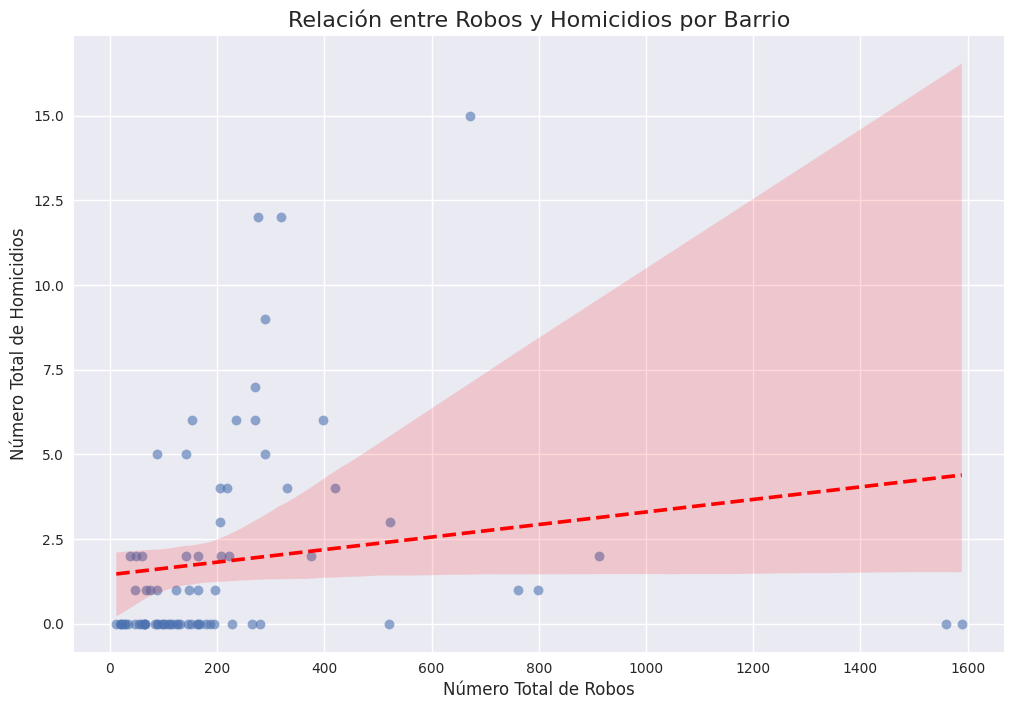

In [8]:
# Utilice este espacio para escribir el código.
# --- 1. Preparar el entorno de la gráfica ---
plt.figure(figsize=(12, 8)) # Define un buen tamaño para la gráfica

# --- 2. Generar la gráfica de dispersión y la recta de regresión ---
# Usar el dataframe 'df_final' que no incluye la fila de totales para no distorsionar la regresión.
sns.regplot(
    data=df_final,
    x='Total Robos',
    y='Total Homicidios',
    scatter_kws={'alpha': 0.6, 's': 50}, # Estilo para los puntos: transparencia y tamaño
    line_kws={'color': 'red', 'linestyle': '--'} # Estilo para la línea de regresión
)

# --- 3. Añadir títulos y etiquetas para mayor claridad ---
plt.title('Relación entre Robos y Homicidios por Barrio', fontsize=16)
plt.xlabel('Número Total de Robos', fontsize=12)
plt.ylabel('Número Total de Homicidios', fontsize=12)
plt.grid(True) # Añade una grilla al fondo

# --- 4. Mostrar la gráfica ---
plt.show()

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

### 3. Distribución espacial del delito

#### 3.1 Distribución respecto al centro de la ciudad

Tomando como centro de la ciudad las coordenadas (-87.627800, 41.881998), estime funciones de densidad que muestren gráficamente el gradiente del total de robos, y homicidios, como función de la distancia al centro de la ciudad. Explique cómo midió las distancias incluyendo que medida de distancia utilizó. Para elegir el ancho de banda y la función de kernel más apropiados utilice validación cruzada usando todas las opciones posibles de kernel. Describa los resultados que obtiene.

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

### 3.2 Puntos calientes en la ciudad

Usando `statsmodels` implemente la estimación de densidad bivariada para el total de robos y el total de homicidios. Muestre los resultados usando curvas de nivel en una visualización interactiva. Compare los resultados de estimar usando los anchos de banda: `normal_reference` y `cv_ml`. Explique en que consisten ambas formas de estimar el ancho de banda. Comente sobre los puntos calientes encontrados bajo ambos métodos y su ubicación en la ciudad. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

In [ ]:
# Utilice este espacio para escribir el código.

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)

## 4. Explicando la ubicación del delito

El objetivo de este punto es encontrar posibles correlaciones  entre el crimen y características de la ciudad. Para ello, utilice los datos de OpenStreetMap y explore si existe una correlación entre el porcentaje del área de la comunidad  dedicado a tiendas (`retail`)  y comercios (`commercial`) y el número total de robos y homicidios en esa comunidad. Ofrezca una explicación intuitiva de por qué cree que aparecen estas correlaciones. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))

In [9]:
# Utilice este espacio para escribir el código.
fp = get_data("chicago")
osm = OSM(fp)

In [10]:
chicago_area_df.columns

Index(['area', 'area_num_1', 'area_numbe', 'comarea', 'comarea_id',
       'community', 'perimeter', 'shape_area', 'shape_len', 'geometry'],
      dtype='object')

In [11]:
# super_commercial = osm.get_landuse(custom_filter={"landuse": ["commercial"]})

(Utilice este espacio para describir el procedimiento, análisis, y conclusiones)